In [1]:
import torchvision

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

torch.Size([3, 224, 224])

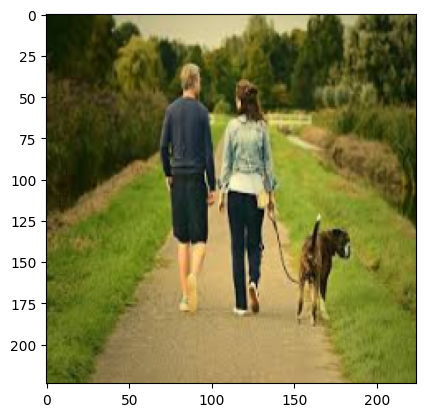

In [2]:
import cv2
import matplotlib.pyplot as plt
import torch

img = cv2.resize(cv2.imread("images/image.jpeg"), (224, 224))

plt.imshow(img[:,:,::-1])

img = torch.tensor(img).permute(2,0,1) / 255
img.shape

In [3]:
model.eval()

preds = model([img])[0]

In [4]:
def draw_boxes(img, boxes, labels, scores, threshold=0.5):
    result = img.copy()

    for bbox, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = bbox.int().tolist()
        if score > threshold:
            cv2.rectangle(
                result, (x1, y1), (x2, y2),
                (0, 255, 0), 2
            )

            cv2.putText(
                result, str(label), (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.3, (0,255,0), 2
            )

    return result

In [5]:
npimg = img.permute(1,2,0).numpy()

In [6]:
img_drawed = draw_boxes(npimg, preds['boxes'], preds['labels'], preds['scores'])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


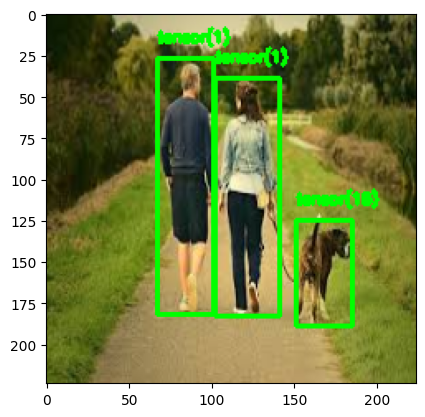

In [7]:
plt.imshow(img_drawed[:,:,::-1])

In [8]:
from src.models.backbone import build_backbone
from src.models.fpn import FPN
from src.models.anchor import AnchorGenerator
from src.models.head import Head
import yaml

with open("config_resnet50.yaml") as f:
    cfg = yaml.safe_load(f)

NUM_CLASSES = cfg['MODEL']['NUM_CLASSES']

backbone = build_backbone(cfg['MODEL']['BACKBONE'])
backbone.eval()

x = img.unsqueeze(dim=0)

features = backbone(x)

In [9]:
for feat in features:
    print(feat.shape)

torch.Size([1, 256, 56, 56])
torch.Size([1, 512, 28, 28])
torch.Size([1, 1024, 14, 14])
torch.Size([1, 2048, 7, 7])


In [10]:
fpn = FPN(
    in_channels=cfg['MODEL']['FPN']['IN_CHANNELS'],
    out_channels=cfg['MODEL']['FPN']['OUT_CHANNELS']
)

fpn.eval()

pyramid = fpn(features)

for feat in pyramid:
    print(feat.shape)

torch.Size([1, 256, 56, 56])
torch.Size([1, 256, 28, 28])
torch.Size([1, 256, 14, 14])
torch.Size([1, 256, 7, 7])


In [11]:
anchor = AnchorGenerator(
    sizes=cfg['MODEL']['ANCHORS']['SIZES'],
    aspect_ratios=cfg['MODEL']['ANCHORS']['RATIOS'],
    strides=cfg['MODEL']['ANCHORS']['STRIDES']
)

anchors_all = anchor(pyramid)
for anchors in anchors_all:
    print(anchors.shape)

torch.Size([9408, 4])
torch.Size([2352, 4])
torch.Size([588, 4])
torch.Size([147, 4])


/home/antonio-fernandes/projects/object_detector/env/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [12]:
anchors_all = torch.cat(anchors_all, dim=0)
anchors_all.shape

torch.Size([12495, 4])

In [13]:
head = Head(
    in_channels=cfg['MODEL']['HEAD']['CHANNELS'], 
    num_anchors=len(cfg['MODEL']['ANCHORS']['RATIOS']),
    num_classes=cfg['MODEL']['NUM_CLASSES'],
    num_convs=cfg['MODEL']['HEAD']['NUM_CONVS']
)
head.eval()

cls_outputs, box_outputs = head(pyramid)

cls_outputs[0].shape, box_outputs[0].shape

(torch.Size([1, 240, 56, 56]), torch.Size([1, 12, 56, 56]))

In [14]:
def decode_boxes(anchors, deltas):

    widths  = anchors[:,2] - anchors[:,0]
    heights = anchors[:,3] - anchors[:,1]

    ctr_x = anchors[:,0] + 0.5 * widths
    ctr_y = anchors[:,1] + 0.5 * heights

    dx, dy, dw, dh = deltas.T

    pred_ctr_x = ctr_x + dx * widths
    pred_ctr_y = ctr_y + dy * heights

    pred_w = widths * torch.exp(dw)
    pred_h = heights * torch.exp(dh)

    x1 = pred_ctr_x - 0.5 * pred_w
    y1 = pred_ctr_y - 0.5 * pred_h
    x2 = pred_ctr_x + 0.5 * pred_w
    y2 = pred_ctr_y + 0.5 * pred_h

    return torch.stack([x1,y1,x2,y2], dim=1)

In [15]:
bbox = []

for outputs in box_outputs:
    bbox.append(outputs.permute(0,2,3,1).reshape(-1,4))

bbox = torch.cat(bbox, dim=0)

boxes = decode_boxes(anchors_all, bbox)
boxes.shape

torch.Size([12495, 4])

In [16]:
logits = []

for outputs in cls_outputs:
    logits.append(outputs.permute(0,2,3,1).reshape(-1, NUM_CLASSES))

logits = torch.cat(logits, dim=0)

scores = torch.softmax(logits, dim=1)
scores, labels = scores.max(dim=1)
labels.shape

torch.Size([12495])

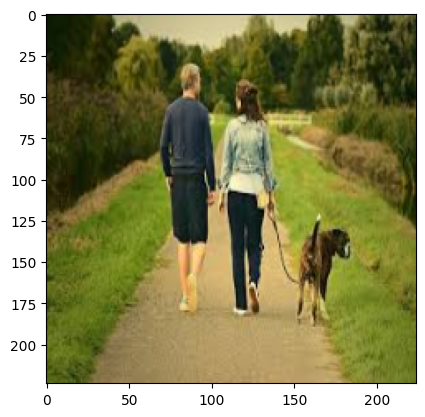

In [17]:
drawed_img = draw_boxes(npimg, boxes, labels, scores, threshold=0.6)

plt.imshow(drawed_img[:, :, ::-1])

In [18]:
gt_box = preds['boxes'][preds['scores'] > 0.5]
gt_cls = preds['labels'][preds['scores'] > 0.5]

In [19]:
gt_box, gt_cls

(tensor([[102.3064,  39.2922, 141.0794, 183.1221],
         [ 67.7991,  27.3585, 101.6942, 182.1316],
         [151.6727, 125.1775, 185.1213, 189.6141]], grad_fn=<IndexBackward0>),
 tensor([ 1,  1, 18]))

In [ ]:
from src.utils import match_anchors

box_labels, gt_idx = match_anchors(anchors_all, gt_box)

In [40]:
print("positive:", (box_labels==1).sum())
print("negative:", (box_labels==0).sum())
print("ignore:", (box_labels==-1).sum())

positive: tensor(5)
negative: tensor(12461)
ignore: tensor(29)


In [ ]:
from src.utils import encode_boxes

box_targets = encode_boxes(anchors_all, gt_box[gt_idx])

In [24]:
from src.losses import compute_losses

cls_loss, box_loss = compute_losses(
    logits, bbox, box_labels, gt_cls[gt_idx], box_targets, NUM_CLASSES
)

In [25]:
print("cls_loss:", cls_loss.item())
print("bbox_loss:", box_loss.item())

cls_loss: 1.4513236284255981
bbox_loss: 0.3963913023471832


In [ ]:
from src.models.detector import Detector

model = Detector(cfg['MODEL'])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
x = x.to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
)


In [67]:
box_labels

tensor([0, 0, 0,  ..., 0, 0, 0])

In [ ]:
for i in range(10000):

    model.train()

    cls_outputs, box_outputs, _ = model(x)

    bbox = []

    for outputs in box_outputs:
        bbox.append(outputs.permute(0,2,3,1).reshape(-1,4))

    bbox = torch.cat(bbox, dim=0)

    logits = []

    for outputs in cls_outputs:
        logits.append(outputs.permute(0,2,3,1).reshape(-1, NUM_CLASSES))

    logits = torch.cat(logits, dim=0)

    with torch.no_grad():

        box_labels, gt_idx = match_anchors(anchors_all, gt_box)

        box_targets = encode_boxes(anchors_all, gt_box[gt_idx])
    
    cls_labels = gt_cls[gt_idx]

    box_labels = box_labels.to(device)
    box_targets = box_targets.to(device)
    cls_labels = cls_labels.to(device)

    cls_loss, box_loss = compute_losses(
        logits, bbox, box_labels, cls_labels, box_targets, NUM_CLASSES
    )

    loss = cls_loss + box_loss

    optimizer.zero_grad()

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(), 10
    ) 

    optimizer.step()

    print(f'iter {i}:', loss.item())

    

NameError: name 'model' is not defined

In [34]:
model.eval()

cls_outputs, box_outputs = model(x)

bbox = []

for outputs in box_outputs:
    bbox.append(outputs.permute(0,2,3,1).reshape(-1,4))

bbox = torch.cat(bbox, dim=0)

boxes = decode_boxes(anchors_all, bbox)

logits = []

for outputs in cls_outputs:
    logits.append(outputs.permute(0,2,3,1).reshape(-1, NUM_CLASSES))

logits = torch.cat(logits, dim=0)

scores = torch.softmax(logits, dim=1)
scores, labels = scores.max(dim=1)
labels.shape

torch.Size([12495])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


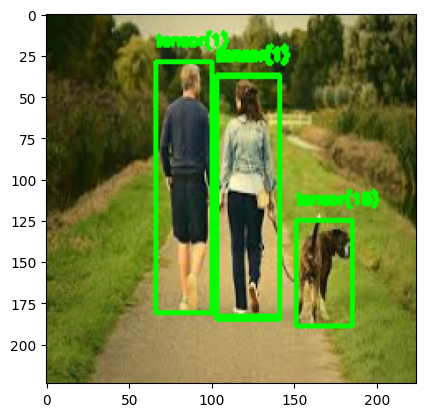

In [37]:
drawed_img = draw_boxes(npimg, boxes, labels, scores, threshold=0.9)

plt.imshow(drawed_img[:, :, ::-1])

In [57]:
x

tensor([[[[0.0157, 0.0157, 0.0118,  ..., 0.2157, 0.1373, 0.1569],
          [0.0157, 0.0157, 0.0118,  ..., 0.1961, 0.1412, 0.1569],
          [0.0157, 0.0118, 0.0118,  ..., 0.1922, 0.1490, 0.1412],
          ...,
          [0.1020, 0.0941, 0.0824,  ..., 0.1412, 0.1451, 0.1412],
          [0.1059, 0.0941, 0.0784,  ..., 0.1255, 0.1294, 0.1255],
          [0.0745, 0.0980, 0.1216,  ..., 0.1137, 0.1137, 0.1137]],

         [[0.0941, 0.0980, 0.1020,  ..., 0.3961, 0.3373, 0.3608],
          [0.0941, 0.0980, 0.1059,  ..., 0.3647, 0.3333, 0.3490],
          [0.0941, 0.0980, 0.1020,  ..., 0.3529, 0.3255, 0.3176],
          ...,
          [0.4196, 0.4078, 0.4000,  ..., 0.4863, 0.4941, 0.4902],
          [0.4235, 0.4118, 0.3961,  ..., 0.4706, 0.4706, 0.4706],
          [0.3961, 0.4157, 0.4392,  ..., 0.4549, 0.4471, 0.4510]],

         [[0.0431, 0.0431, 0.0471,  ..., 0.4000, 0.3373, 0.3608],
          [0.0431, 0.0431, 0.0471,  ..., 0.3725, 0.3294, 0.3529],
          [0.0431, 0.0431, 0.0471,  ..., 0